In [4]:
import os
import numpy as np
import networkx as nx

from src.OrganoidMesh import OrganoidMesh
from src.cell_graph_functions import *
from src.nuclei_to_mesh_projection import *
from src.mesh_analysis import *
from src.crypt_extraction import *
from src.organoid_plotting import *

In [5]:
# # ---------------------------------------------------------------------------
# # Configuration / paths
# # ---------------------------------------------------------------------------

# data_dir = '../NicoleData/20250929/fractal_output'

# # --- path to your cell nucleus table ---
# CELLS_CSV = "../NicoleData/features_csv/features/cell_types_class.csv"   # <-- adjust

# timepoint = "day4p5"
# zarr_name = "r0.zarr"
# well = "A06"
# round_name = "0_fused_zillum_registered"
# organoid_id = 31 #19 # example


# # timepoint = "day4"
# # zarr_name = "r0.zarr"
# # well = "A05"
# # round_name = "0_fused_zillum_registered"
# # organoid_id = 79


# # timepoint = "day4"
# # zarr_name = "r0.zarr"
# # well = "B01"
# # round_name = "0_fused_zillum_registered"
# # organoid_id = 83


# # timepoint = "day4"
# # zarr_name = "r0.zarr"
# # well = "A04"
# # round_name = "0_fused_zillum_registered"
# # organoid_id = 89


# mesh_path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class/{organoid_id}.vtp"
# cells_df = pd.read_csv(CELLS_CSV)


# marker_names = ['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB',
#                 'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']

In [ ]:
# ---------------------------------------------------------------------------
# Configuration / paths
# ---------------------------------------------------------------------------

data_dir = '../NicoleData/20251201/fractal_output'

# --- path to your cell nucleus table ---
CELLS_CSV = "../NicoleData/20251201/cell_features_class.csv"   # <-- adjust

timepoint = "day4p5"
zarr_name = "251130R0.zarr"
well = "B02"
round_name = "2_zillum_registered"
organoid_id = 6 #19 # example


MARKER_COLS = [
    '0.C02.percentile99_class', # LGR5
    '0.C03.percentile99_class', # chroma
    '0.C04.percentile99_class', # aldoB
    '1.C02.percentile99_class', # Sero
    '1.C03.percentile99_class', # Lyz
    '1.C04.percentile99_class', # Agr2
    '2.C04.percentile99_class', # ki67
]

coexpress_markers=(
    "1.C03.percentile99_class",     # Lysozyme → Paneth
    "1.C04.percentile99_class",     # Agr2 → Goblet/Paneth
    "1.C02.percentile99_class",    # Serotonin → Enterochromaffin
    "0.C03.percentile99_class",  # Chromogranin A → Enteroendocrine
),
lgr5_marker="0.C02.percentile99_class"

marker_names = ['LGR5', 'Chromogranin A', 'AldoB', 'Serotonin', 'Lysozyme', 'Agr2', 'ki67']

mesh_path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_corrected_annotated_by_projection/{organoid_id}.vtp"
cells_df = pd.read_csv(CELLS_CSV)



### Project nuclei to mesh and tessellate

In [7]:
organoid_id = os.path.splitext(os.path.basename(mesh_path))[0]
label_uid = f"{timepoint}_{well}_{organoid_id}"

nuclei_df_org = cells_df[cells_df["label_uid"] == label_uid].copy()

# 1) load membrane mesh as an OrganoidMesh
mesh = OrganoidMesh(mesh_path)

# 2) extract per-cell attributes
nuclei_xyz, markers_bin = extract_cell_attributes(nuclei_df_org)

_, nuclei_xyz = center_and_rescale_mesh(mesh, nuclei_xyz)
markers_bin = filter_lgr5_coexpression(markers_bin, marker_names=MARKER_COLS, coexpress_markers=coexpress_markers, lgr5_marker=lgr5_marker) 

# 3) project nuclei -> mesh vertices (using geometry from the mesh object)
proj_vertex_ids, proj_points = project_nuclei_to_mesh(
    nuclei_xyz,
    mesh,
    resolve_duplicates=True,
)

# store eigen-decomposition for geodesics (if needed by compute_geodesics)
mesh._eig_decomp()

# 4) geodesic distances + Voronoi assignment
dist_mat, vertex_owner = compute_geodesic_voronoi(mesh, proj_vertex_ids)

# 5) build graph from Voronoi partition 
G = build_cell_graph_from_voronoi(
    nuclei_xyz,
    markers_bin,
    mesh,            
    vertex_owner,
    proj_vertex_ids,
    proj_points,
)

Duplicate projections: 3 vertices with duplicates, 3 duplicate cell pairs.


heat sources: 100%|██████████| 675/675 [00:05<00:00, 115.91it/s]


In [8]:
t_hks = [1.0, 2.0, 4.0, 8.0, 25.0] 
HKS = compute_hks(mesh, t=t_hks, coeffs=False)   # (V, T)

# store times as graph-level metadata (no need to duplicate per node)
add_vertex_field_to_graph(G, HKS, "hks")

# Compute encoing
vocab = np.load('./sim/vocab.npz', allow_pickle=True)

encoding, _, _, _ = compute_vocabulary_encoding(vocab, mesh)
add_vertex_field_to_graph(G, encoding, "vocab_encoding")

In [9]:
fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=mesh.v[:,0], y=mesh.v[:,1], z=mesh.v[:,2],
        i=mesh.f[:,0], j=mesh.f[:,1], k=mesh.f[:,2],
        intensity=HKS[:,0]-np.mean(HKS[:,0]),
        colorscale='RdBu_r',
        cmid=0,
    )
)

### Segment crypts and villus from vocab

In [10]:
crypt_vocab_idx = [1, 2, 7]
neck_vocab_idx = [0,3,4]

crypts, necks, villus = segment_organoid_from_vocab(
    G,
    crypt_vocab_idx=crypt_vocab_idx,
    crypt_thresh=0.2,
    min_crypt_region_size=10,
    neck_vocab_idx=neck_vocab_idx,
    neck_thresh=0.5,
)

In [11]:
fig = plot_organoid_graph(proj_points, G, HKS[:,0], node_size=2)
# add_region_overlays(fig, proj_points, crypts, colorscale='YlOrRd')
# add_region_overlays(fig, proj_points, villus, colorscale='viridis')
add_region_overlays(fig, proj_points, necks, colorscale='viridis')


fig.show()

In [12]:

crypts, necks, villus = grow_crypts_toward_necks(
    G,
    crypt_regions=crypts,
    neck_regions=necks,   # [] is fine if you didn’t extract necks
    N=2,
    min_villus_region_size=1,
)

fig = plot_organoid_graph(proj_points, G, HKS[:,0], node_size=2)
add_region_overlays(fig, proj_points, crypts, colorscale='YlOrRd')
add_region_overlays(fig, proj_points, necks, colorscale='viridis')

fig.show()


### Extract crypt composition

In [13]:
def filter_crypt_by_markers(
    G,
    crypt_cells,
    pos_markers=None,     # list[int]
    neg_markers=None,     # list[int]
    pos_min_cells=1,
    neg_min_cells=1,
    roi_frac=None,        # e.g. 0.3 -> use cells with dist_bottom <= 0.3
    dist_bottom=None,     # (N_cells,) normalized distances
    require_all_pos=True,
):
    """
    Return True if crypt passes marker filters, else False.

    Rules
    -----
    - Positive markers: require >= pos_min_cells in ROI
    - Negative markers: reject if >= neg_min_cells in ROI
    - ROI = all crypt cells, or if roi_frac is given:
            cells with dist_bottom <= roi_frac
    """

    if not crypt_cells:
        return False

    pos_markers = [] if pos_markers is None else [int(k) for k in pos_markers]
    neg_markers = [] if neg_markers is None else [int(k) for k in neg_markers]

    crypt_idx = np.fromiter(set(crypt_cells), dtype=np.int64)

    # -----------------------------
    # ROI selection
    # -----------------------------
    if roi_frac is not None:
        if dist_bottom is None:
            raise ValueError("dist_bottom required when roi_frac is used.")
        Db = np.asarray(dist_bottom, float)[crypt_idx]
        roi_idx = crypt_idx[np.isfinite(Db) & (Db <= float(roi_frac))]
        if roi_idx.size == 0:
            return False
    else:
        roi_idx = crypt_idx

    # -----------------------------
    # Count marker-positive cells
    # -----------------------------
    needed = sorted(set(pos_markers + neg_markers))
    counts = {k: 0 for k in needed}

    for cid in roi_idx:
        mb = np.asarray(G.nodes[int(cid)]["markers_bin"], dtype=np.int64)
        for k in needed:
            counts[k] += int(mb[k])

    # -----------------------------
    # Positive marker rule
    # -----------------------------
    if pos_markers:
        ok = [(counts[k] >= pos_min_cells) for k in pos_markers]
        if require_all_pos:
            if not all(ok):
                return False
        else:
            if not any(ok):
                return False

    # -----------------------------
    # Negative marker rule
    # -----------------------------
    for k in neg_markers:
        if counts[k] >= neg_min_cells:
            return False

    return True


In [15]:
from src.crypt_analysis import *


from scipy.interpolate import interp1d

def warp_circumference_cubic(s_old, C_old, s_star):
    s_query = s_old * s_star

    mask = np.isfinite(C_old)
    f = interp1d(
        s_old[mask],
        C_old[mask],
        kind="cubic",
        bounds_error=False,
        fill_value=np.nan,
    )
    return f(s_query)



crypt_patches = as_patch_list(crypts)
villus_patches = as_patch_list(villus)
neck_patches = as_patch_list(necks) if "necks" in globals() and necks is not None else []

# combine villus + neck into boundary patches
boundary_patches = []
if villus_patches:
    boundary_patches.extend(villus_patches)
if neck_patches:
    boundary_patches.extend(neck_patches)

# ----------------------------
# config
# ----------------------------
S = 1.5
n_bins = 80
bin_edges   = np.linspace(0.0, S, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bin_edges_raw = np.linspace(0.0, 10.0, n_bins + 1)  # adjust if you want per-crypt max

# ----------------------------
# storage
# ----------------------------
M = markers_bin.shape[1]
num_pos_per_bin   = np.zeros((M, n_bins), dtype=float)
num_cells_per_bin = np.zeros((n_bins,), dtype=float)

crypt_circumferences = np.zeros((len(crypt_patches), n_bins), dtype=float)
crypt_circumferences_adj = np.zeros((len(crypt_patches), n_bins), dtype=float)
crypt_circumferences_int = np.zeros((len(crypt_patches), n_bins), dtype=float)

dnorm_cellcenters_crypts = np.zeros((len(crypt_patches), G.number_of_nodes()), dtype=float)

corrs_raw  = []
corrs_norm = []

curv_mean = np.zeros((len(crypt_patches), n_bins), dtype=float)
curv_std = np.zeros((len(crypt_patches), n_bins), dtype=float)

# cell-center vertex ids (stored in graph nodes as "proj_vertex")
proj_vertex_ids = np.array([int(G.nodes[i]["proj_vertex"]) for i in range(G.number_of_nodes())], dtype=np.int64)

# per-vertex weights (optional)
w_v = vertex_areas(mesh)

for j, crypt_cells in enumerate(crypt_patches):

    # --- neck cells touching this crypt (use your original intention: only touching neck/villus) ---
    # if you don't have per-crypt touching neck patches, use all neck cells:
    neck_boundary_cells = crypt_neck_boundary_cells(G, crypt_cells, boundary_patches)
    if len(neck_boundary_cells) == 0:
        print('hej')
        continue

    # --- (1) find crypt bottom (NO dist_mat) ---
    bottom_cell_id, bottom_score = find_crypt_bottom_lightweight(
        G=G,
        mesh=mesh,
        crypt_cells=crypt_cells,
        neck_boundary_cells=neck_boundary_cells,
        candidates="all",  # or int for speed (e.g. 60)
        score="cv",
    )

    # --- (2) compute crypt distance field from bottom via heat method and normalize by mean boundary distance ---
    dnorm_vertices, dist_vertices, dnorm_cellcenters, dist_cellcenters, L_mean = calculate_crypt_distance(
        mesh=mesh,
        G=G,
        bottom_cell_id=bottom_cell_id,
        neck_boundary_cells=neck_boundary_cells,
        t=None,
        compute_geodesics_fn=compute_geodesics, # <-- your existing heat-method routine
    )

    # --- (3) circumference vs distance (FULL mesh; extends into villus if S>1) ---
    crypt_circumferences[j, :] = crypt_circumference(
        mesh=mesh,
        crypt_dist=dnorm_vertices,
        levels=bin_centers,
    )


    s_star = adjust_cryptlength_by_circumference(
        s=bin_centers,
        C=crypt_circumferences[j],
        search_interval=(0.75, 1.25),
        window_length=9,
        polyorder=3,
        min_prominence=0.05,  # optional
    )

    L_crypt = L_mean * s_star 
    dnorm_cellcenters /= s_star
    dnorm_vertices /= s_star

    dnorm_cellcenters_crypts[j, :] = dnorm_cellcenters

    crypt_circumferences_adj[j, :] = crypt_circumference(
        mesh=mesh,
        crypt_dist=dnorm_vertices,
        levels=bin_centers,
    )

    # interpolate C_old(s_old) onto s_query
    crypt_circumferences_int[j,:] = warp_circumference_cubic(bin_centers, crypt_circumferences[j], s_star)


    # --- (4) marker positivity vs distance (cell centers; extends into villus if S>1) ---
    counts_pos, counts_total = bin_marker_positivity(
        markers=markers_bin,
        distance=dnorm_cellcenters,
        bin_edges=bin_edges,
    )
    num_pos_per_bin   += counts_pos
    num_cells_per_bin += counts_total

    # --- (5) anchored correlations (raw + normalized) ---
    # Use vertex-level HKS/field; here: HKS at time index 0
    c_raw, Ns_raw, r_centers = crypt_anchored_correlation(
        X_vertices=HKS[:, 0],
        crypt_dist=dist_vertices,
        bin_edges=bin_edges_raw,
        weights=w_v,
        connected=True,
        normalized=False,
        exclude_self=True,
    )

    c_norm, Ns_norm, s_centers = crypt_anchored_correlation(
        X_vertices=HKS[:, 0],
        crypt_dist=dnorm_vertices,
        bin_edges=bin_edges,
        weights=w_v,
        connected=True,
        normalized=False,
        exclude_self=True,
    )

    corrs_raw.append(c_raw)
    corrs_norm.append(c_norm)


    curv_mean[j,:], curv_std[j,:], _ = field_stats_along_crypt(HKS[:, 0], dnorm_vertices, bin_edges, weights=w_v)

    BI, CI, EI = compute_crypt_metrics(
        s=bin_centers,
        C=crypt_circumferences_adj[j],     # or crypt_circumferences[j] if already aligned
        L=L_crypt,
        mu_hks=curv_mean[j],
        std_hks=curv_std[j],
    )

    print(BI, CI, EI)



    # i_LGR5 = 0
    # i_AldoB = 4
    # i_Lyzo = 9
    # i_Sero = 8 
    # keep = filter_crypt_by_markers(
    #     G,
    #     crypt_cells,
    #     pos_markers=[i_Lyzo, i_Sero],
    #     neg_markers=[i_AldoB],
    #     pos_min_cells=1,
    #     neg_min_cells=1,
    #     roi_frac=1.0,
    #     dist_bottom=dnorm_cellcenters,
    #     require_all_pos=False
    # )

    # print(keep)



corrs_raw  = np.asarray(corrs_raw)
corrs_norm = np.asarray(corrs_norm)


heat sources: 100%|██████████| 1/1 [00:00<00:00, 108.12it/s]


0.12276947935933546 0.01650454327505819 0.4522425325211885


heat sources: 100%|██████████| 1/1 [00:00<00:00, 106.07it/s]


0.06943739261822401 0.012420296604040372 0.3789478527903117


In [16]:
crypt_patches_new, _, _ = assign_crypts_by_neckline(dnorm_cellcenters_crypts)


fig = plot_organoid_graph(proj_points, G, None, node_size=3)
add_region_overlays(fig, proj_points, crypt_patches_new)


fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
        camera=dict(
            eye=dict(x=1.0, y=0, z=1.0),   # camera position
            center=dict(x=0, y=0, z=0),      # look-at point
            up=dict(x=0, y=0, z=1),          # which direction is "up"
        )
    )
)


fig.update_layout(height=550, width=750, title='HKS')
fig.show()

# fig.write_image("single_organoid_crypt_segmantation.svg")

/tmp/ipykernel_182190/2969048659.py:18: RuntimeWarning:

invalid value encountered in divide



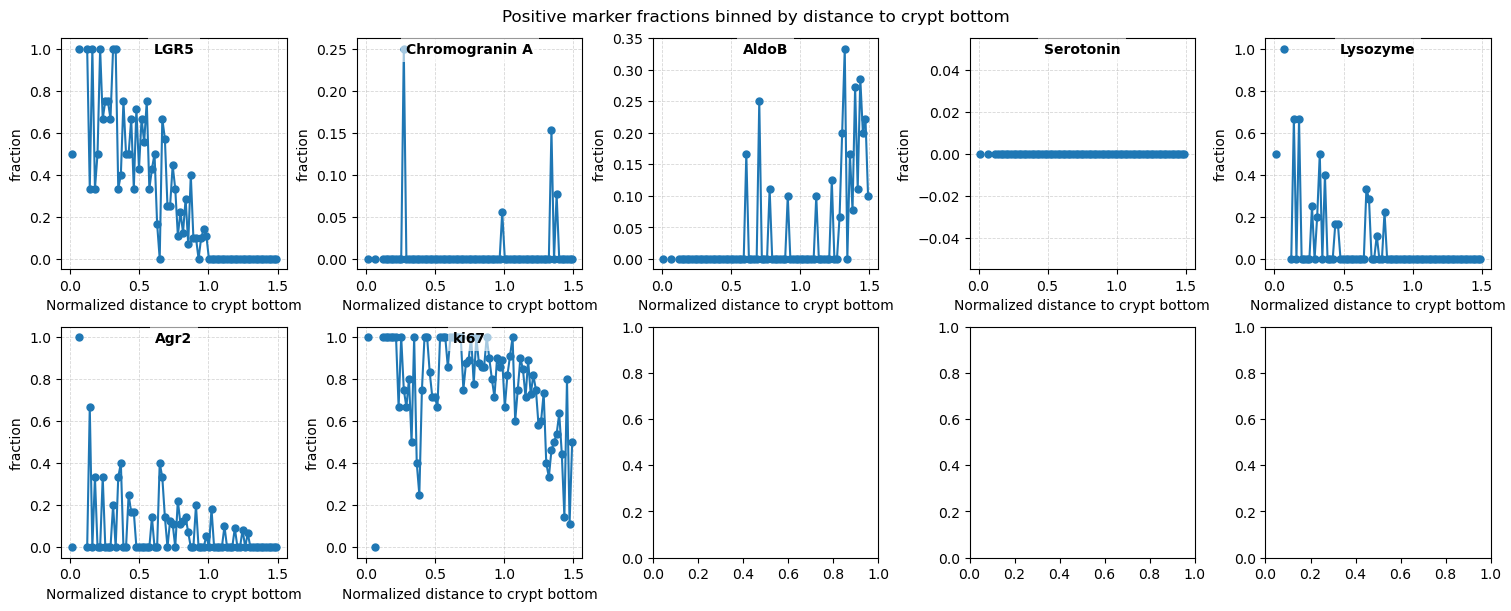

In [17]:
import matplotlib.pyplot as plt

M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers, num_pos_per_bin[i,:]/num_cells_per_bin, marker='o', linewidth=1.5, markersize=5)

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("fraction")

plt.suptitle("Positive marker fractions binned by distance to crypt bottom")
plt.show()


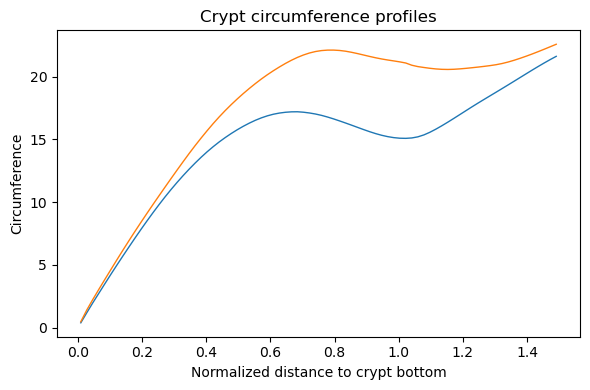

In [18]:
plt.figure(figsize=(6, 4))

for i in range(crypt_circumferences.shape[0]):
    plt.plot(bin_centers, crypt_circumferences[i], linewidth=1.0)

plt.xlabel("Normalized distance to crypt bottom")
plt.ylabel("Circumference")
plt.title("Crypt circumference profiles")
plt.tight_layout()
plt.show()

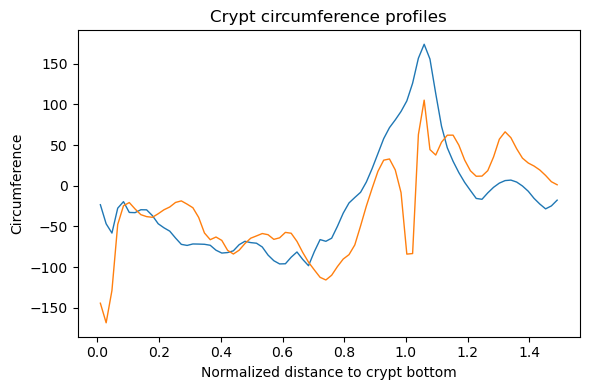

In [19]:
plt.figure(figsize=(6, 4))

for i in range(crypt_circumferences.shape[0]):
    plt.plot(bin_centers, np.gradient(np.gradient(crypt_circumferences[i],bin_centers), bin_centers), linewidth=1.0)

plt.xlabel("Normalized distance to crypt bottom")
plt.ylabel("Circumference")
plt.title("Crypt circumference profiles")
plt.tight_layout()
plt.show()

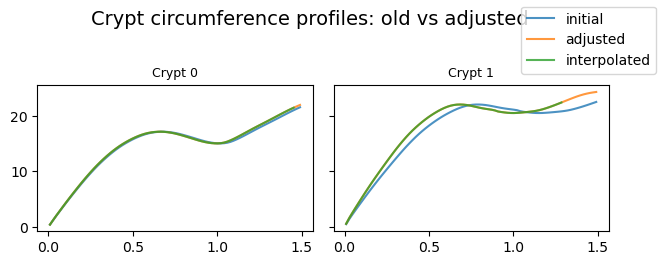

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math


n_crypts = crypt_circumferences.shape[0]

# --- choose subplot grid ---
n_cols = int(np.ceil(np.sqrt(n_crypts)))
n_rows = int(np.ceil(n_crypts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5*n_cols, 2.8*n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)  # flatten in case of 2D grid

for i in range(n_crypts):
    ax = axes[i]

    # plot old
    ax.plot(bin_centers, crypt_circumferences[i], linewidth=1.5, alpha=0.8, label="initial")
    ax.plot(bin_centers, crypt_circumferences_adj[i], linewidth=1.5, alpha=0.8, label="adjusted")
    ax.plot(bin_centers, crypt_circumferences_int[i], linewidth=1.5, alpha=0.8, label="interpolated")

    ax.set_title(f"Crypt {i}", fontsize=9)

# hide unused subplots
for k in range(n_crypts, len(axes)):
    axes[k].axis("off")

# global labels
fig.suptitle("Crypt circumference profiles: old vs adjusted", fontsize=14)

# single legend (from first axis)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


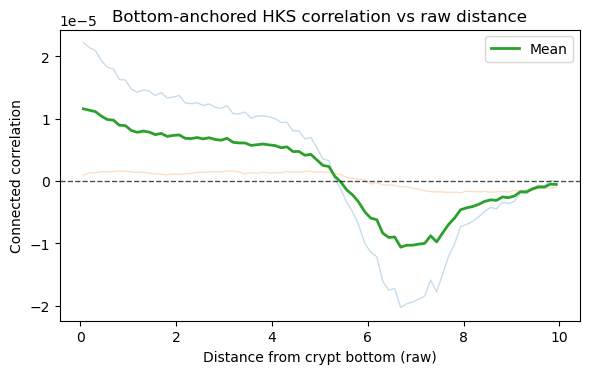

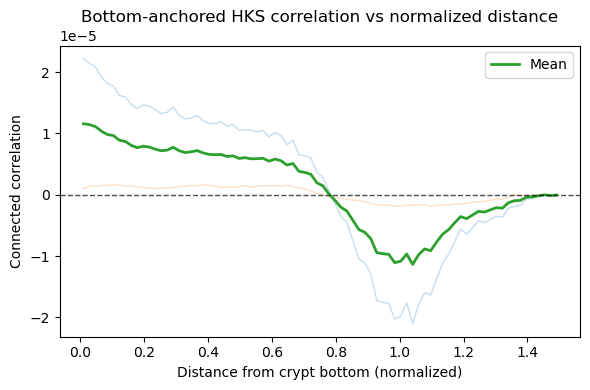

In [21]:
# -------- Figure 1: RAW distance --------
plt.figure(figsize=(6, 4))

for i in range(corrs_raw.shape[0]):
    plt.plot(r_centers, corrs_raw[i], alpha=0.25, linewidth=1.0)

mean_raw = np.nanmean(corrs_raw, axis=0)
plt.plot(r_centers, mean_raw, linewidth=2.0, label="Mean")
plt.axhline(0.0, linestyle="--", linewidth=1.0, color="black", alpha=0.7)

plt.xlabel("Distance from crypt bottom (raw)")
plt.ylabel("Connected correlation")
plt.title("Bottom-anchored HKS correlation vs raw distance")
plt.legend()
plt.tight_layout()
plt.show()


# -------- Figure 2: NORMALIZED distance --------
plt.figure(figsize=(6, 4))

for i in range(corrs_norm.shape[0]):
    plt.plot(s_centers, corrs_norm[i], alpha=0.25, linewidth=1.0)

mean_norm = np.nanmean(corrs_norm, axis=0)
plt.plot(s_centers, mean_norm, linewidth=2.0, label="Mean")
plt.axhline(0.0, linestyle="--", linewidth=1.0, color="black", alpha=0.7)

plt.xlabel("Distance from crypt bottom (normalized)")
plt.ylabel("Connected correlation")
plt.title("Bottom-anchored HKS correlation vs normalized distance")
plt.legend()
plt.tight_layout()
plt.show()



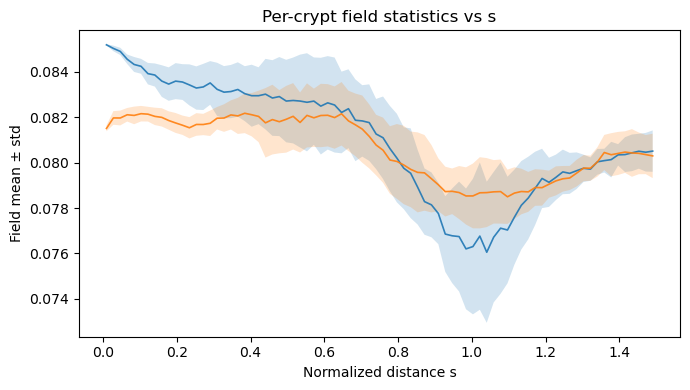

In [22]:
plt.figure(figsize=(7, 4))

for j in range(curv_mean.shape[0]):
    x = bin_centers
    y = curv_mean[j]
    ylo = y - curv_std[j]
    yhi = y + curv_std[j]

    plt.plot(x, y, linewidth=1.2, alpha=0.9)
    plt.fill_between(x, ylo, yhi, alpha=0.2)

plt.xlabel("Normalized distance s")
plt.ylabel("Field mean ± std")
plt.title("Per-crypt field statistics vs s")
plt.tight_layout()
plt.show()

In [23]:
from src.organoid_plotting import plot_organoid_graph


bin_markers_cell = np.asarray([G.nodes[n]["markers_bin"] for n in G.nodes], dtype=np.int64)

print(bin_markers_cell.shape)

N = bin_markers_cell.shape[0]



colors = np.full(N, "darkgray", dtype=object)  # baseline

colors[bin_markers_cell[:,0] == 1] = "#1f77b4"   # blue
colors[bin_markers_cell[:,4] == 1] = "#2ca02c"   # green
colors[bin_markers_cell[:,8] == 1] = "#d62728"   # red
colors[bin_markers_cell[:,9] == 1] = "#9467bd"   # purple


fig = plot_organoid_graph(
    proj_points,
    G,
    node_values=colors,   # <--- important
    node_size=5,
    edge_width=3.0,
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-0.8, y=-0.8, z=1.2)   # position of the camera
    )
)

fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
    )
)

legend_traces = [
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#1f77b4"),
        name="stem cell (LGR5+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#d62728"),
        name="enterochromaffin (Serotonin+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#2ca02c"),
        name="absorptive (AldoB+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#9467bd"),
        name="paneth (Lysozyme+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color='darkgray'),
        name="other",
        showlegend=True
    ),
]

for tr in legend_traces:
    fig.add_trace(tr)

fig.update_layout(height=550, width=750)
fig.show()


(675, 7)


IndexError: index 8 is out of bounds for axis 1 with size 7

In [ ]:
n_cells = G.number_of_nodes()
num_crypts = len(crypt_patches_new)

# centroids: (N_cells, 3)
centroids_all = np.vstack([np.asarray(G.nodes[n]["proj_point"], dtype=float) for n in range(n_cells)])

crypt_sizes = np.zeros(num_crypts, dtype=float)

for j, crypt_cells in enumerate(crypt_patches_new):
    idx = np.fromiter(crypt_cells, dtype=int)
    crypt_sizes[j] = float(idx.size)


# absolute diffs (upper triangle)
diff = crypt_sizes[:, None] - crypt_sizes[None, :]
size_diff = (diff[np.triu_indices(num_crypts, k=1)])

min_size = float(np.min(crypt_sizes))
size_diff_rel = (diff[np.triu_indices(num_crypts, k=1)] / max(min_size, 1e-8))


# Compute crypt angles
com_org = np.nanmean(centroids_all, axis=0)

rays = []
com_crypts = []
for patch in crypt_patches_new:
    idx = np.fromiter(patch, dtype=int)
    com_crypt = np.nanmean(centroids_all[idx, :], axis=0)
    rays.append(com_crypt - com_org)
    com_crypts.append(com_crypt)

com_crypts = np.asarray(com_crypts, dtype=float)   # now shape (num_crypts, 3)

rays = np.asarray(rays, dtype=float)  # (num_crypts, 3)
norms = np.linalg.norm(rays, axis=1)
valid = np.isfinite(norms) & (norms > 0)

Rn = np.zeros_like(rays)
Rn[valid] = rays[valid] / norms[valid, None]

cosM = np.clip(Rn @ Rn.T, -1.0, 1.0)
theta = np.degrees(np.arccos(cosM))
angles_deg = (theta[np.triu_indices(num_crypts, k=1)])


In [ ]:
# --- build figure using your existing plotting functions
fig = plot_organoid_graph(proj_points, G, None, node_size=3)
add_region_overlays(fig, proj_points, crypt_patches_new)

# --- add rays (one trace per crypt)
for j in np.where(valid)[0]:
    c = com_crypts[j]
    fig.add_trace(go.Scatter3d(
        x=[com_org[0], c[0]],
        y=[com_org[1], c[1]],
        z=[com_org[2], c[2]],
        mode="lines",
        line=dict(width=6),   # set width; add color="..." if you want fixed color
        name=f"ray {j}",
        showlegend=False
    ))

# (optional) show the organoid COM and crypt COM points too
fig.add_trace(go.Scatter3d(
    x=[com_org[0]], y=[com_org[1]], z=[com_org[2]],
    mode="markers", marker=dict(size=6),
    name="organoid COM", showlegend=False
))
fig.add_trace(go.Scatter3d(
    x=com_crypts[valid, 0], y=com_crypts[valid, 1], z=com_crypts[valid, 2],
    mode="markers", marker=dict(size=4),
    name="crypt COMs", showlegend=False
))

# your existing layout tweaks
fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',
        camera=dict(
            eye=dict(x=1.0, y=0, z=1.0),
            center=dict(x=0, y=0, z=0),
            up=dict(x=0, y=0, z=1),
        ),
    ),
    height=550, width=750,
)

fig.show()